In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv


In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
data = pd.read_csv("/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv", encoding="latin-1")

In [4]:
data = data[['v1', 'v2']]
data.columns = ['label', 'message']
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
data['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

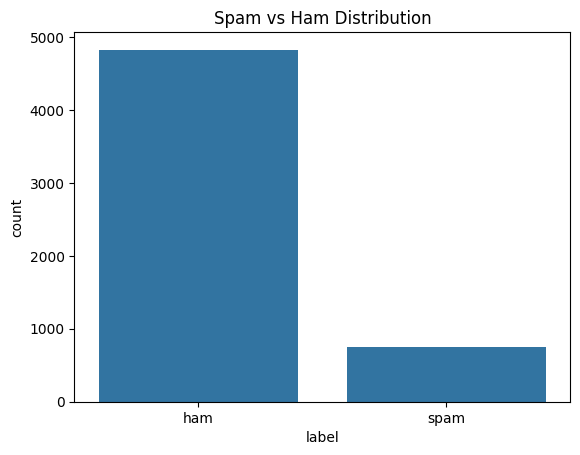

In [7]:
sns.countplot(x='label', data=data)
plt.title("Spam vs Ham Distribution")
plt.show()

In [8]:
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

In [9]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=3000
)

X = tfidf.fit_transform(data['message'])
y = data['label']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
data = pd.read_csv(
    "/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv",
    encoding="latin-1"
)

data = data[['v1', 'v2']]
data.columns = ['label', 'message']

In [12]:
data['label'] = data['label'].astype(str)

In [13]:
data['label'] = data['label'].str.strip().str.lower()

In [14]:
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

In [15]:
data = data.dropna(subset=['label'])

In [16]:
print(data['label'].isna().sum())   # should be 0
print(data['label'].value_counts())

0
label
0    4825
1     747
Name: count, dtype: int64


In [17]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=3000
)

X = tfidf.fit_transform(data['message'])
y = data['label']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9829596412556054
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



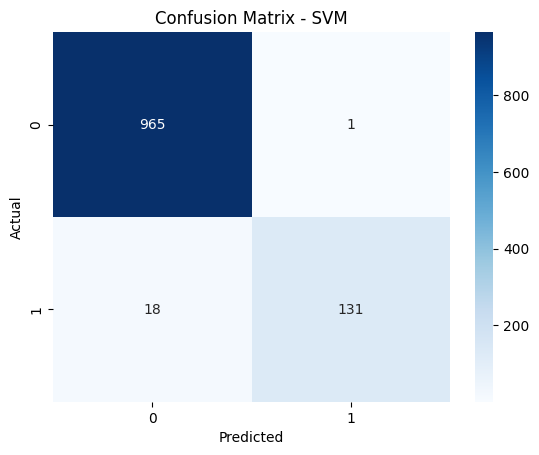

In [20]:
cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

In [21]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9748878923766816
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       0.99      0.82      0.90       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



In [22]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9695067264573991
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [23]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9829596412556054
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [24]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

results

,Model,Accuracy
0,Naive Bayes,0.974888
1,Logistic Regression,0.969507
2,SVM,0.982960


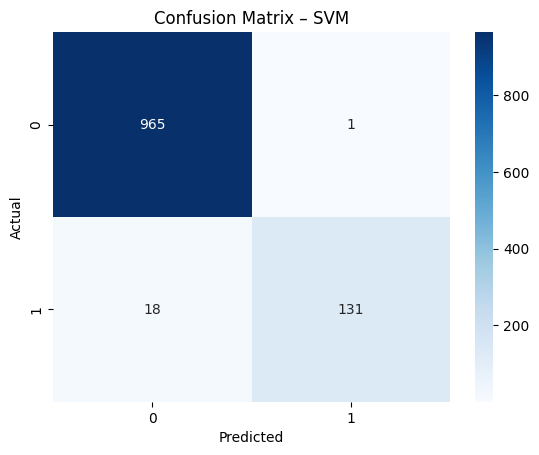

In [25]:
cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – SVM")
plt.show()

In [26]:
def predict_sms(text):
    text_vec = tfidf.transform([text])
    pred = svm_model.predict(text_vec)
    return "SPAM 🚫" if pred[0] == 1 else "HAM ✅"

predict_sms("Congratulations! You won a free iPhone")

'SPAM 🚫'

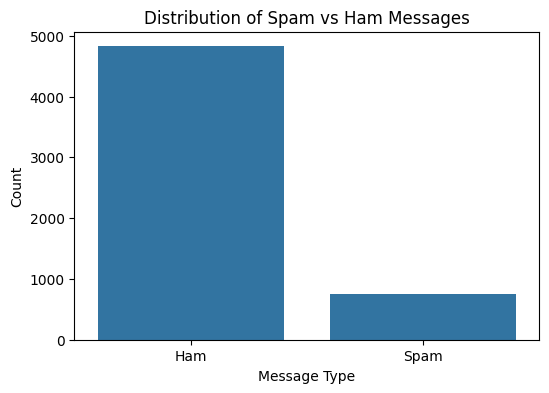

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=data)
plt.xticks([0,1], ['Ham', 'Spam'])
plt.title("Distribution of Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

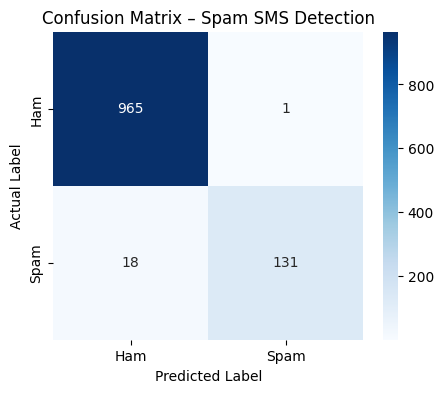

In [28]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix – Spam SMS Detection")
plt.show()

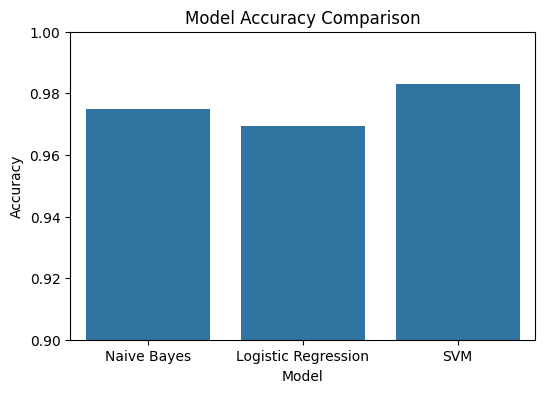

In [29]:
accuracy_df = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df)
plt.ylim(0.9, 1.0)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [30]:
coefficients = svm_model.coef_[0]

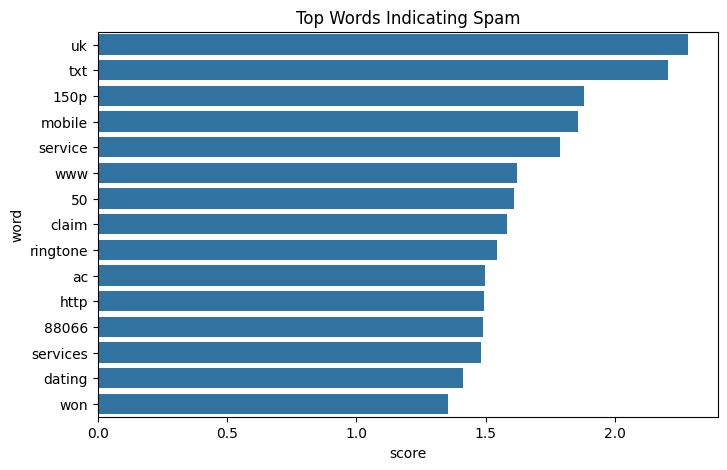

In [31]:
feature_names = tfidf.get_feature_names_out()
coefficients = svm_model.coef_[0]   # FIX HERE

top_spam_words = pd.DataFrame({
    'word': feature_names,
    'score': coefficients
}).sort_values(by='score', ascending=False).head(15)

plt.figure(figsize=(8,5))
sns.barplot(x='score', y='word', data=top_spam_words)
plt.title("Top Words Indicating Spam")
plt.show()

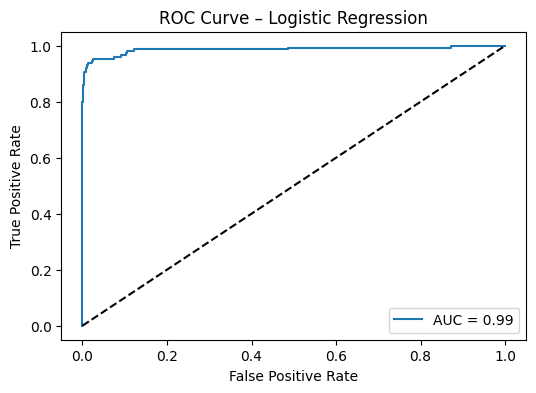

In [32]:
from sklearn.metrics import roc_curve, auc

y_scores = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()

In [33]:
def predict_sms_final(text):
    vec = tfidf.transform([text])
    pred = svm_model.predict(vec)
    return "SPAM 🚫" if pred[0] == 1 else "HAM ✅"

predict_sms_final("You have won a free reward, claim now!")

'SPAM 🚫'

In [34]:
final_results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Remarks": [
        "Fast baseline model",
        "Good probability estimation",
        "Best overall performance"
    ]
})

final_results

,Model,Accuracy,Remarks
0,Naive Bayes,0.974888,Fast baseline model
1,Logistic Regression,0.969507,Good probability estimation
2,SVM,0.982960,Best overall performance
